In [20]:
%load_ext autoreload
%autoreload 2

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

from utils import add_temp_errors, extract_digits_from_answers, merge_with_indomain_year_only
from prediction_analysis import calc_final_scores

In [2]:
palm = pd.read_csv(
    "./../../models/predictions/PaLM/fewshot_with_reasoning/indomain_eval_palm_few_shot_with_reasoning.csv"
).drop(columns="Unnamed: 0")
palm.shape

(1851, 4)

In [3]:
palm.head()

,table,question,predicted_answer,actual_answer
0,2,How many years did Art Carney as actor since 1...,54 years && Carney started acting in 1939 and ...,54 Years
1,2,Who was the spouse of Art Carney in 1970?,Barbara Isaac && The passage states that Art C...,Barbara Isaac
2,2,How many total years was Art Carney married to...,25 years && 1965 - 1940,28 years
3,2,Which spouse was Art Carney married to the least?,Barbara Isaac && Barbara Isaac was married to ...,Barbara Isaac
4,2,Who was Art Carney married to when he served i...,Jean Myers && He was married to Jean Myers fro...,Jean Myers


In [4]:
temp_err_df = merge_with_indomain_year_only(palm)
temp_err_df.head()

,question,answer,table_id,predicted_answer
0,How many years did Art Carney as actor since 1...,54 Years,2,54 years && Carney started acting in 1939 and ...
1,How many total years was Art Carney married to...,28 years,2,25 years && 1965 - 1940
2,How many years before he died was Art Carney m...,23,2,6 && 1993 - 1980 = 6
3,How old was Art Carney when he first got divor...,47,2,47 years old && 1965 - 1918 = 47
4,How many years ago did Art Carney was died?,19 Years ago,2,19 years && 2022 - 2003


In [5]:
temp_err_df = extract_digits_from_answers(temp_err_df)
temp_err_df.head()

,question,answer,table_id,predicted_answer,predicted_answer_old,predicted_answer_wo_reas,answer_digits,predicted_answer_digits
0,How many years did Art Carney as actor since 1...,54 Years,2,54 years,54 years && Carney started acting in 1939 and ...,54 years,[54],[54]
1,How many total years was Art Carney married to...,28 years,2,25 years,25 years && 1965 - 1940,25 years,[28],[25]
2,How many years before he died was Art Carney m...,23,2,6,6 && 1993 - 1980 = 6,6,[23],[6]
3,How old was Art Carney when he first got divor...,47,2,47 years old,47 years old && 1965 - 1918 = 47,47 years old,[47],[47]
4,How many years ago did Art Carney was died?,19 Years ago,2,19 years,19 years && 2022 - 2003,19 years,[19],[19]


In [6]:
temp_err_single_digit_df = temp_err_df.query(
    "answer_digits.str.len()==1 and predicted_answer_digits.str.len()==1"
)
temp_err_single_digit_df.shape

(829, 8)

In [7]:
temp_err_single_digit_df = add_temp_errors(temp_err_single_digit_df)
temp_err_single_digit_df.head()

,question,answer,table_id,predicted_answer,predicted_answer_old,predicted_answer_wo_reas,answer_digits,predicted_answer_digits,err,rel_err,abs_err,abs_per_err,log_err
0,How many years did Art Carney as actor since 1...,54 Years,2,54 years,54 years && Carney started acting in 1939 and ...,54 years,54,54,0,0.000000,0,0.000000,0.000000
1,How many total years was Art Carney married to...,28 years,2,25 years,25 years && 1965 - 1940,25 years,28,25,-3,-0.107143,3,10.714286,-0.109199
2,How many years before he died was Art Carney m...,23,2,6,6 && 1993 - 1980 = 6,6,23,6,-17,-0.739130,17,73.913043,-1.232144
3,How old was Art Carney when he first got divor...,47,2,47 years old,47 years old && 1965 - 1918 = 47,47 years old,47,47,0,0.000000,0,0.000000,0.000000
4,How many years ago did Art Carney was died?,19 Years ago,2,19 years,19 years && 2022 - 2003,19 years,19,19,0,0.000000,0,0.000000,0.000000


In [8]:
temp_err_single_digit_df.query("rel_err!=rel_err")

,question,answer,table_id,predicted_answer,predicted_answer_old,predicted_answer_wo_reas,answer_digits,predicted_answer_digits,err,rel_err,abs_err,abs_per_err,log_err
150,How many years after Rudolf Thienel became Pre...,0,254,0,0 && Rudolf Thienel became President in 2014 a...,0,0,0,0,NaN,0,NaN,0.0
692,How many years after Becca Balint became Presi...,0,936,0,0 && 2021 - 2021 = 0,0,0,0,0,NaN,0,NaN,0.0


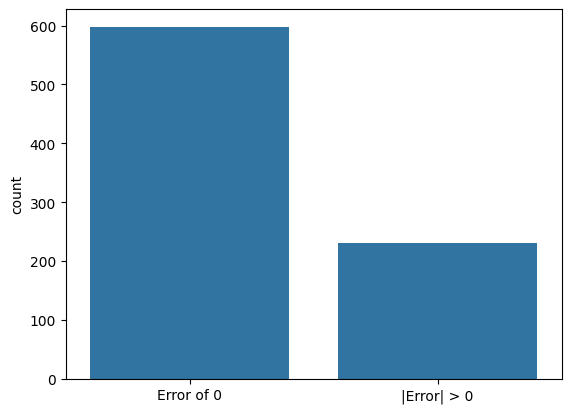

In [9]:
ax = sns.countplot(x=np.where(temp_err_single_digit_df["err"] == 0, "Error of 0", "|Error| > 0"))

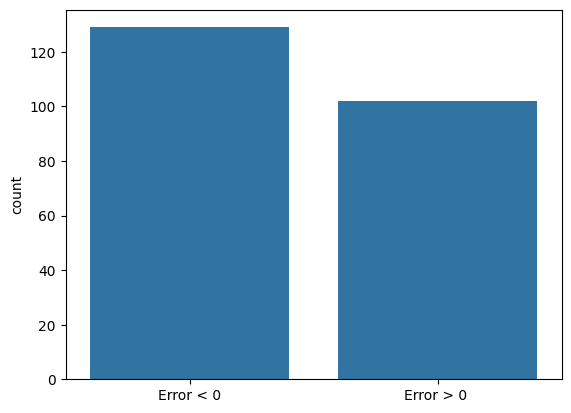

In [10]:
ax = sns.countplot(
    x=np.where(temp_err_single_digit_df.query("err!=0")["err"] > 0, "Error > 0 ", "Error < 0")
)

<Axes: ylabel='rel_err'>

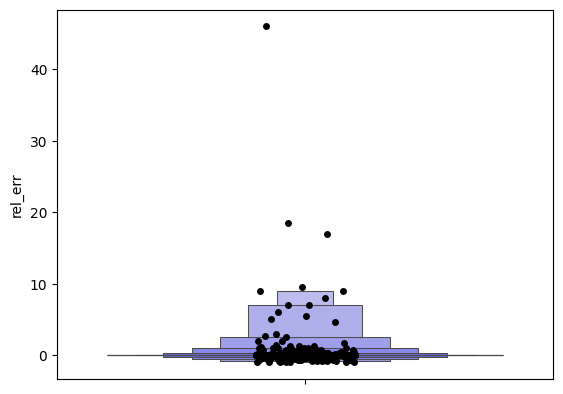

In [11]:
ax = sns.boxenplot(
    temp_err_single_digit_df.query("err.abs() < 100"),
    y="rel_err",
    color="b",
    width_method="linear",
    k_depth="trustworthy",
    outlier_prop=0.007,
    showfliers=False,
)
# ax.set_yscale("symlog")
sns.stripplot(data=temp_err_single_digit_df.query("err.abs()<200"), y="rel_err", color="k", ax=ax)

In [12]:
temp_err_single_digit_df.loc[:, "err"].value_counts().iloc[:10]

err
 0     598
-1      53
 1      36
-10     12
 4      12
-2      10
-3       9
 10      9
 2       8
-4       7
Name: count, dtype: int64

In [13]:
temp_err_single_digit_df.loc[:, "abs_err"].value_counts().iloc[:10]

abs_err
0     598
1      89
10     21
4      19
2      18
3      14
8       7
6       6
9       6
5       6
Name: count, dtype: int64

In [14]:
temp_err_single_digit_df.query("abs_err > 100").loc[:, "abs_err"]

28      500
29      138
35      433
320     136
534     200
535     153
552    1988
Name: abs_err, dtype: int64

In [15]:
rel_error = temp_err_single_digit_df.rel_err
rel_error = rel_error[np.isfinite(rel_error)]
err = temp_err_single_digit_df.err
abs_err = temp_err_single_digit_df.abs_err


print(f"Mean error in years: {np.mean(err).round(2)} ± {np.std(err).round(2)}")
print(f"Mean |error| in years: {np.mean(abs_err).round(2)} ± {np.std(abs_err).round(2)}")
print(f"Mean rel. error: {np.mean(rel_error).round(2)} ± {np.std(rel_error).round(2)}")
print(f"Mean rel. error, where error > 0: {np.mean(rel_error[rel_error > 0]).round(2)} ± {np.std(rel_error[rel_error > 0]).round(2)}")
print(f"Mean rel. error, where error < 0: {np.mean(rel_error[rel_error < 0]).round(2)} ± {np.std(rel_error[rel_error < 0]).round(2)}")

Mean error in years: 2.0 ± 74.12
Mean |error| in years: 6.46 ± 73.87
Mean rel. error: 0.73 ± 14.06
Mean rel. error, where error > 0: 6.35 ± 39.76
Mean rel. error, where error < 0: -0.29 ± 0.31


In [16]:
calc_final_scores(temp_err_single_digit_df.rename(columns={"answer": "actual_answer", "predicted_answer": "predicted_answer_new", "predicted_answer_old": "predicted_answer"}))

{'f1': 69.32985595345617,
 'EM': 63.93244873341375,
 'ROUGE1': 0.692577977668923,
 'ROUGE2': 0.6922576886844222,
 'METERO': 0.47354735402425663}

In [17]:
temp_err_single_digit_df[np.isfinite(temp_err_single_digit_df.abs_per_err)].abs_per_err.mean()

82.14129877111729

In [18]:
temp_err_single_digit_df[np.isfinite(temp_err_single_digit_df.abs_per_err)].abs_per_err.quantile(0.90)

45.33001245330012

In [19]:
temp_err_single_digit_df[np.isfinite(temp_err_single_digit_df.abs_per_err)].abs_per_err.median()

0.0